# Tree Species Classification Project

## Author
Ruut Hyvösaho

## Purpose

The purpose of this notebook is to explore the tree species dataset and to study transfer learning methods for tree species recognition.



## Dataset Overview

In this section, the dataset structure and image examples are inspected.

In [39]:
import os

dataset_path = "tree_dataset"

print(os.path.exists(dataset_path))

True


In [40]:
import os

dataset_path = "tree_dataset"

classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 3
['test', 'train', 'val']


In [41]:
print(os.listdir("tree_dataset"))


['test', 'train', 'val']


In [42]:
from torchvision import datasets, transforms
2
import os

In [43]:
data_dir = "tree_dataset"

train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "train")
)

print(train_dataset.classes)


['Acer palmatum', 'Cedrus deodara', 'Celtis sinensis', 'Cinnamomum camphora (Linn) Presl', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Koelreuteria paniculata', 'Lagerstroemia indica', 'Liquidambar formosana', 'Liriodendron chinense', 'Magnolia grandiflora L', 'Magnolia liliflora Desr', 'Michelia chapensis', 'Osmanthus fragrans', 'Photinia serratifolia', 'Platanus', 'Prunus cerasifera f. atropurpurea', 'Salix babylonica', 'Sapindus saponaria', 'Styphnolobium japonicum', 'Triadica sebifera', 'Zelkova serrata']


## Dataset classes

The tree species dataset contains multiple tree classes. The number of classes was inspected before model training.

In [44]:
print("Number of classes:", len(train_dataset.classes))

Number of classes: 23


In [45]:
print("Training images:", len(train_dataset))

Training images: 3850


Class: Acer palmatum


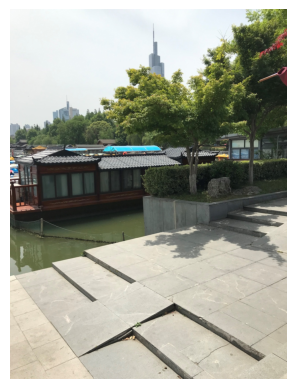

In [46]:
from PIL import Image
import matplotlib.pyplot as plt

image_path, label = train_dataset.samples[0]

img = Image.open(image_path)

print("Class:", train_dataset.classes[label])

plt.imshow(img)
plt.axis("off")
plt.show()

In [47]:
print("Number of classes:", len(train_dataset.classes))
print(train_dataset.classes[:10])

Number of classes: 23
['Acer palmatum', 'Cedrus deodara', 'Celtis sinensis', 'Cinnamomum camphora (Linn) Presl', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Koelreuteria paniculata', 'Lagerstroemia indica', 'Liquidambar formosana']


## Dataset Overview

The training dataset was loaded using PyTorch ImageFolder.

A total of 23 tree species classes were identified in the dataset.

The class names were automatically extracted from the folder structure.

In [48]:
print("Training images:", len(train_dataset))

Training images: 3850


In [49]:
val_dataset = datasets.ImageFolder("tree_dataset/val")
test_dataset = datasets.ImageFolder("tree_dataset/test")

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3850
Validation: 482
Test: 472


In [50]:
from collections import Counter

class_counts = Counter()

for _, label in train_dataset.samples:
    class_name = train_dataset.classes[label]
    class_counts[class_name] += 1

for tree, count in class_counts.items():
    print(tree, count)

Acer palmatum 162
Cedrus deodara 125
Celtis sinensis 188
Cinnamomum camphora (Linn) Presl 234
Elaeocarpus decipiens 172
Flowering cherry 106
Ginkgo biloba 228
Koelreuteria paniculata 223
Lagerstroemia indica 65
Liquidambar formosana 168
Liriodendron chinense 182
Magnolia grandiflora L 212
Magnolia liliflora Desr 190
Michelia chapensis 154
Osmanthus fragrans 173
Photinia serratifolia 120
Platanus 193
Prunus cerasifera f. atropurpurea 99
Salix babylonica 136
Sapindus saponaria 224
Styphnolobium japonicum 157
Triadica sebifera 154
Zelkova serrata 185


## Example Images

A few example images were inspected manually to understand image quality, background variation and potential challenges for classification.

Class: Acer palmatum


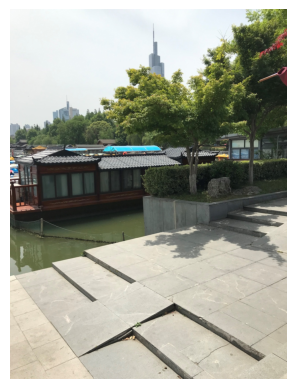

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

image_path, label = train_dataset.samples[0]

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")

print("Class:", train_dataset.classes[label])

plt.show()

# Dataset Exploration

## Number of Classes

The number of tree species in the dataset is examined.

## Image Examples

Sample images from the dataset are displayed for visual inspection.

## Image Size Analysis

Image dimensions are studied before model training.

In [52]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3850
Validation: 482
Test: 472


In [53]:
from PIL import Image

image_path, label = train_dataset.samples[0]

img = Image.open(image_path)

print("Image size:", img.size)

Image size: (1200, 1600)


## Image Size Analysis

A sample image was inspected to determine the image resolution.

The examined image had a resolution of 1200 × 1600 pixels, which is relatively large for CNN training. Therefore, image resizing will likely be required before model training in order to reduce memory usage and training time.

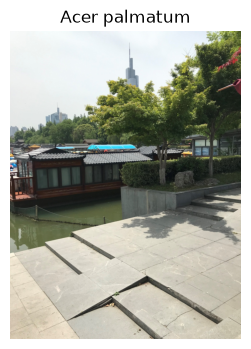

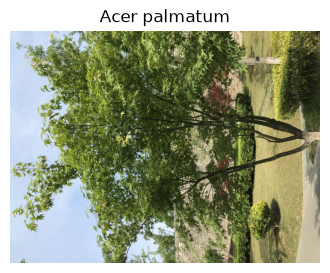

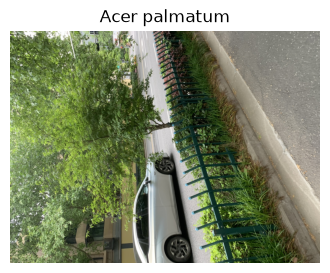

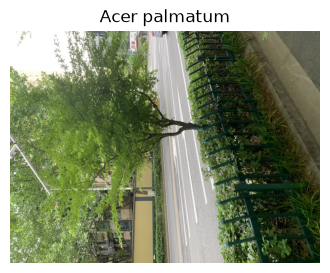

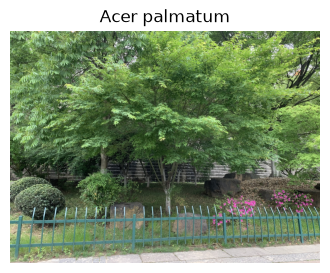

In [54]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(5):
    image_path, label = train_dataset.samples[i]

    img = Image.open(image_path)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(train_dataset.classes[label])
    plt.axis("off")
    plt.show()

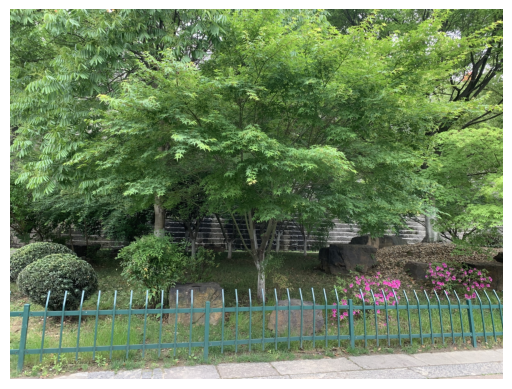

In [55]:
from PIL import Image, ImageOps

img = Image.open(image_path)

img = ImageOps.exif_transpose(img)

plt.imshow(img)
plt.axis("off")
plt.show()

### Initial Observations

Some images appear in different orientations. This may affect classification performance and should be considered during preprocessing and data augmentation.

In [56]:
from collections import Counter

counts = Counter()

for _, label in train_dataset.samples:
    counts[train_dataset.classes[label]] += 1

for name, count in counts.items():
    print(f"{name}: {count}")

Acer palmatum: 162
Cedrus deodara: 125
Celtis sinensis: 188
Cinnamomum camphora (Linn) Presl: 234
Elaeocarpus decipiens: 172
Flowering cherry: 106
Ginkgo biloba: 228
Koelreuteria paniculata: 223
Lagerstroemia indica: 65
Liquidambar formosana: 168
Liriodendron chinense: 182
Magnolia grandiflora L: 212
Magnolia liliflora Desr: 190
Michelia chapensis: 154
Osmanthus fragrans: 173
Photinia serratifolia: 120
Platanus: 193
Prunus cerasifera f. atropurpurea: 99
Salix babylonica: 136
Sapindus saponaria: 224
Styphnolobium japonicum: 157
Triadica sebifera: 154
Zelkova serrata: 185


## Class Distribution

The training dataset contains 23 tree species classes.

## Dataset Summary

The dataset contains 23 tree species classes and a total of 4804 images.

The dataset is divided into three subsets:

- Training set: 3850 images
- Validation set: 482 images
- Test set: 472 images

The predefined data split was used during the project.

## Class Distribution

The training dataset contains 23 tree species classes.

The number of images per class varies from 65 to 234 images. Therefore, the dataset is moderately imbalanced, which may influence the model performance for some classes.

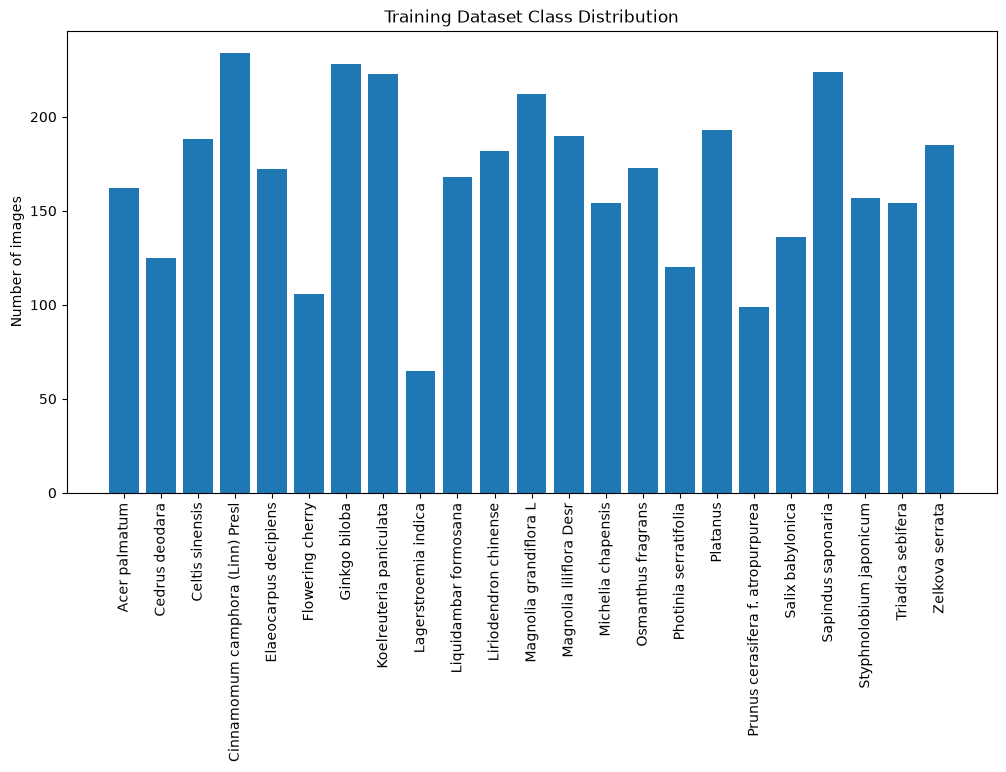

In [57]:
import matplotlib.pyplot as plt

names = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(12,6))
plt.bar(names, values)

plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.title("Training Dataset Class Distribution")

plt.show()

### Initial Observations

- The dataset contains 23 tree species.
- Image resolutions are relatively large.
- Some images appear in different orientations.
- The class distribution is moderately imbalanced.

# Transfer Learning with ResNet18

In this section, a pretrained ResNet18 model is fine-tuned for tree species classification.

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, models, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [59]:
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]),
    "val": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
}

In [60]:
data_dir = "tree_dataset"

image_datasets = {
    "train": datasets.ImageFolder(
        f"{data_dir}/train",
        data_transforms["train"]
    ),
    "val": datasets.ImageFolder(
        f"{data_dir}/val",
        data_transforms["val"]
    )
}


In [61]:
dataloaders = {
    "train": DataLoader(
        image_datasets["train"],
        batch_size=32,
        shuffle=True
    ),
    "val": DataLoader(
        image_datasets["val"],
        batch_size=32,
        shuffle=False
    )
}

dataset_sizes = {
    x: len(image_datasets[x])
    for x in ["train", "val"]
}

class_names = image_datasets["train"].classes

num_classes = len(class_names)

print("Classes:", num_classes)

Classes: 23


In [62]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [63]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    num_classes
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=23, bias=True)


In [64]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## ResNet18 Configuration

A pretrained ResNet18 model was loaded using ImageNet weights.

The final fully connected layer was replaced with a new layer containing 23 output nodes, corresponding to the 23 tree species classes in the dataset.

## Conclusions

The dataset contains 23 tree species and 4804 images.

The folder structure was successfully loaded using PyTorch ImageFolder. Initial inspection of the dataset and transfer learning model structure was performed before starting full model training.